# SIREN Model Visualization - Stanford Bunny

This notebook demonstrates the **SIREN** (Sinusoidal Representation Network) model trained on the Stanford Bunny.

## What is SIREN?
SIREN uses **periodic sine activations**:
$$\phi(x) = \sin(\omega_0 \cdot x)$$

Key properties:
- Periodic activation enables learning high-frequency details
- $\omega_0$ controls frequency (typically 30 for first layer)
- Excellent at representing signals with derivatives

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Define the SIREN Model Architecture

The bunny model has architecture `[2, 32, 32, 32, 32, 1]` with sine activation.

In [14]:
class Sine(nn.Module):
    """Sine activation function with w0 scaling."""
    def __init__(self, w0: float = 1.0):
        super().__init__()
        self.w0 = w0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.w0 * x)


class SimpleSIREN(nn.Module):
    """Simple SIREN for 2D input -> 1D SDF output."""
    def __init__(self, layers=[32, 32, 32, 32], in_features=2, out_features=1, w0=1.0):
        super().__init__()
        
        self.fcs = nn.ModuleList()
        
        # First layer: in -> hidden
        self.fcs.append(nn.Linear(in_features, layers[0]))
        
        # Hidden layers
        for i in range(len(layers) - 1):
            self.fcs.append(nn.Linear(layers[i], layers[i+1]))
        
        # Output layer
        self.fcs.append(nn.Linear(layers[-1], out_features))
        
        self.activation = Sine(w0=w0)
    
    def forward(self, x):
        for i, fc in enumerate(self.fcs[:-1]):
            x = self.activation(fc(x))
        return self.fcs[-1](x)


# Create model with w0=1.0 (plain sine, as used in GeneralNet)
# The bunny model was trained with torch.sin, NOT sin(30*x)
model = SimpleSIREN(layers=[32, 32, 32, 32], in_features=2, out_features=1, w0=1.0)

# Load the trained bunny weights
bunny_path = '../models/bunny/2,32,32,32,32,1,sin,bunny'
state_dict = torch.load(bunny_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✓ Loaded bunny model with sin activation")
print(f"  Architecture: [2, 32, 32, 32, 32, 1]")
print(f"  Activation: sin(x)  (NOT sin(30x) - plain sine)")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Loaded bunny model with sin activation
  Architecture: [2, 32, 32, 32, 32, 1]
  Activation: sin(x)  (NOT sin(30x) - plain sine)
  Parameters: 3,297


## Visualize the Sine Activation Function

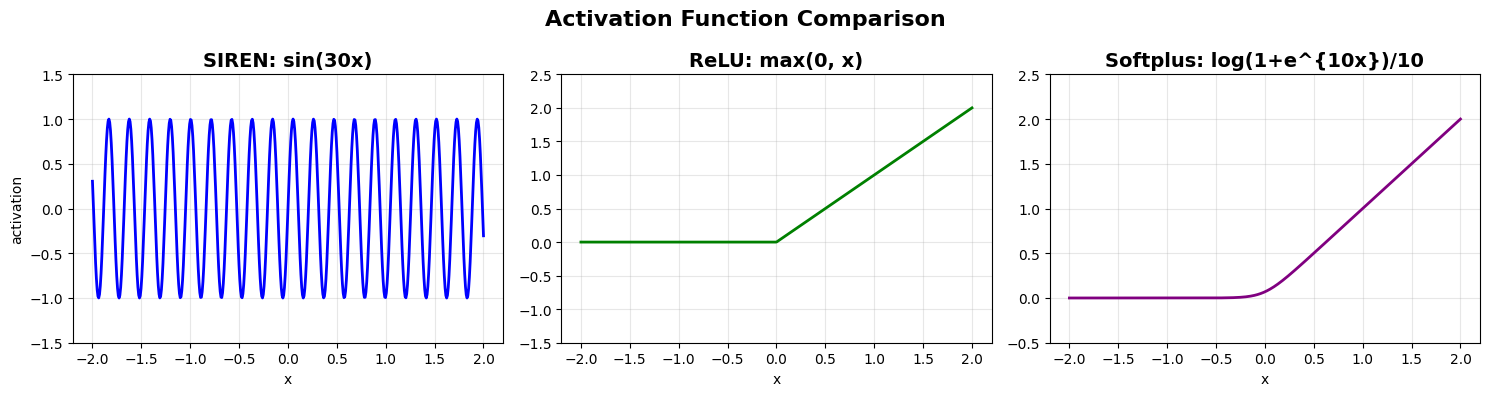

Key insight: SIREN's periodic activation enables learning high-frequency details
that monotonic activations (ReLU, Softplus) struggle with.


In [3]:
# Compare activation functions
x = np.linspace(-2, 2, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SIREN (sin)
w0 = 30
ax = axes[0]
ax.plot(x, np.sin(w0 * x), 'b-', linewidth=2)
ax.set_title(f'SIREN: sin({w0}x)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('activation')
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 1.5)

# ReLU
ax = axes[1]
ax.plot(x, np.maximum(0, x), 'g-', linewidth=2)
ax.set_title('ReLU: max(0, x)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 2.5)

# Softplus
ax = axes[2]
beta = 10
ax.plot(x, np.log(1 + np.exp(beta * x)) / beta, 'purple', linewidth=2)
ax.set_title(f'Softplus: log(1+e^{{{beta}x}})/{beta}', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 2.5)

plt.suptitle('Activation Function Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: SIREN's periodic activation enables learning high-frequency details")
print("that monotonic activations (ReLU, Softplus) struggle with.")

## Generate 2D SDF Visualization of the Bunny

The model takes 2D coordinates (x, y) and outputs a signed distance field (SDF).

In [4]:
# Create 2D grid
resolution = 256
x = np.linspace(-1, 1, resolution)
y = np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(x, y)

# Flatten and convert to tensor
coords = np.stack([xx.flatten(), yy.flatten()], axis=-1)
coords_tensor = torch.from_numpy(coords).float().to(device)

# Evaluate model
with torch.no_grad():
    sdf_values = model(coords_tensor).cpu().numpy()

# Reshape to grid
sdf_grid = sdf_values.reshape(resolution, resolution)

print(f"SDF stats: min={sdf_grid.min():.4f}, max={sdf_grid.max():.4f}, mean={sdf_grid.mean():.4f}")

SDF stats: min=-2.2557, max=0.7434, mean=-0.7458


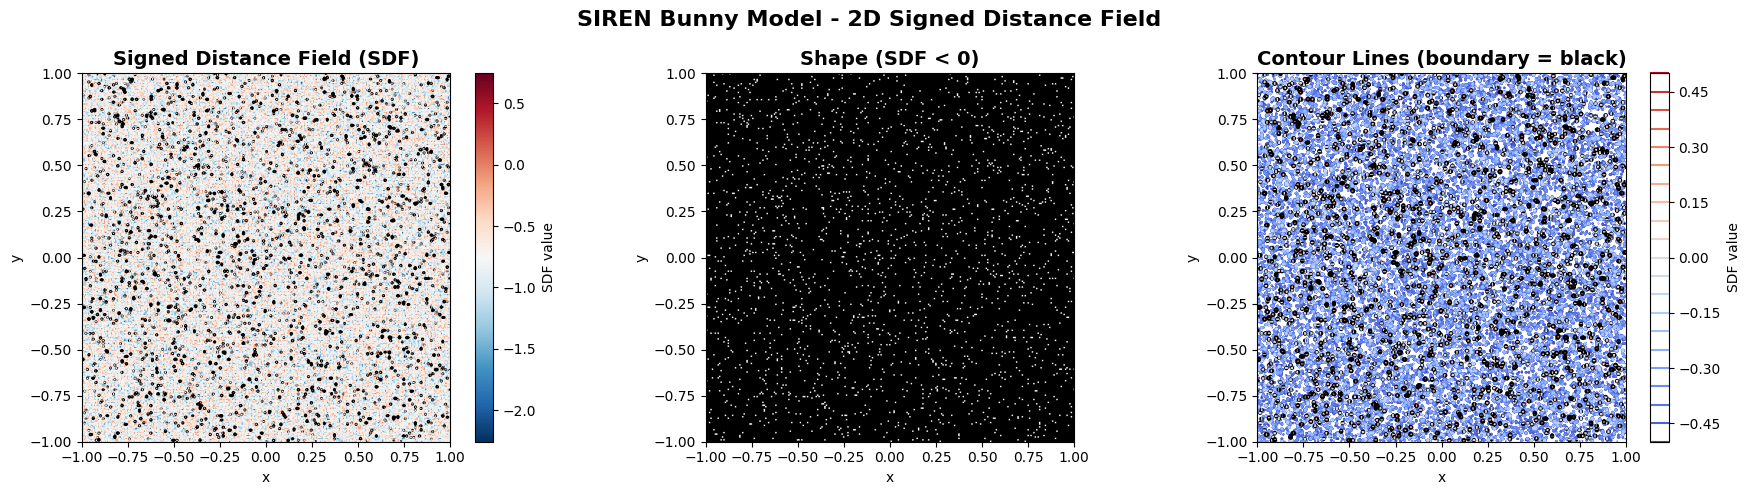

In [5]:
# Visualize the SDF
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. SDF heatmap
ax = axes[0]
im = ax.imshow(sdf_grid, extent=[-1, 1, -1, 1], origin='lower', cmap='RdBu_r')
ax.contour(xx, yy, sdf_grid, levels=[0], colors='black', linewidths=2)
plt.colorbar(im, ax=ax, label='SDF value')
ax.set_title('Signed Distance Field (SDF)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

# 2. Binary shape (inside/outside)
ax = axes[1]
inside = sdf_grid < 0
ax.imshow(inside, extent=[-1, 1, -1, 1], origin='lower', cmap='binary')
ax.set_title('Shape (SDF < 0)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

# 3. Contour lines
ax = axes[2]
contours = ax.contour(xx, yy, sdf_grid, levels=np.linspace(-0.5, 0.5, 21), cmap='coolwarm')
ax.contour(xx, yy, sdf_grid, levels=[0], colors='black', linewidths=3)
plt.colorbar(contours, ax=ax, label='SDF value')
ax.set_title('Contour Lines (boundary = black)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')

plt.suptitle('SIREN Bunny Model - 2D Signed Distance Field', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3D Surface Visualization

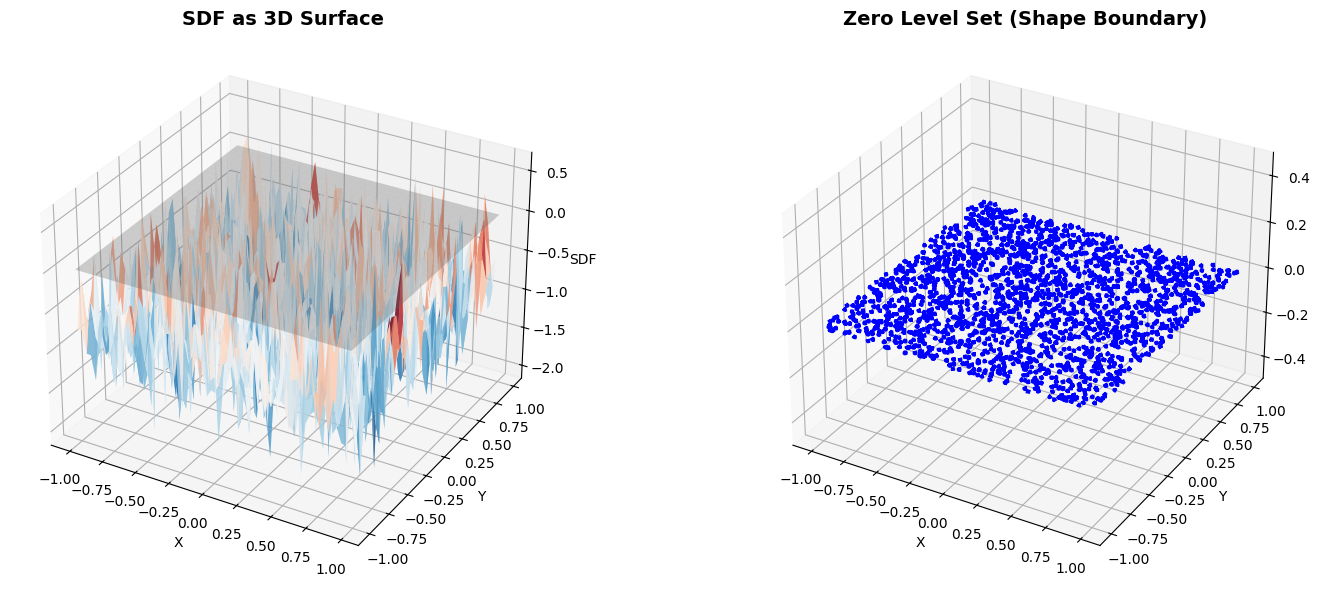

In [6]:
# 3D surface plot of the SDF
fig = plt.figure(figsize=(16, 6))

# Subsample for 3D plot
step = 4
xx_sub = xx[::step, ::step]
yy_sub = yy[::step, ::step]
sdf_sub = sdf_grid[::step, ::step]

# Plot 1: Full SDF surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(xx_sub, yy_sub, sdf_sub, cmap='RdBu_r', alpha=0.8, edgecolor='none')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('SDF')
ax1.set_title('SDF as 3D Surface', fontsize=14, fontweight='bold')

# Add zero plane
ax1.plot_surface(xx_sub, yy_sub, np.zeros_like(sdf_sub), alpha=0.3, color='gray')

# Plot 2: Just the boundary (zero level set)
ax2 = fig.add_subplot(122, projection='3d')

# Extract contour at zero
contours = measure.find_contours(sdf_grid, 0)
for contour in contours:
    # Scale contour to [-1, 1]
    contour_scaled = contour / resolution * 2 - 1
    ax2.plot(contour_scaled[:, 1], contour_scaled[:, 0], 0, 'b-', linewidth=3)

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Zero Level Set (Shape Boundary)', fontsize=14, fontweight='bold')
ax2.set_zlim(-0.5, 0.5)

plt.tight_layout()
plt.show()

## Analyze SIREN's Frequency Response

One key advantage of SIREN is its ability to capture high-frequency details.

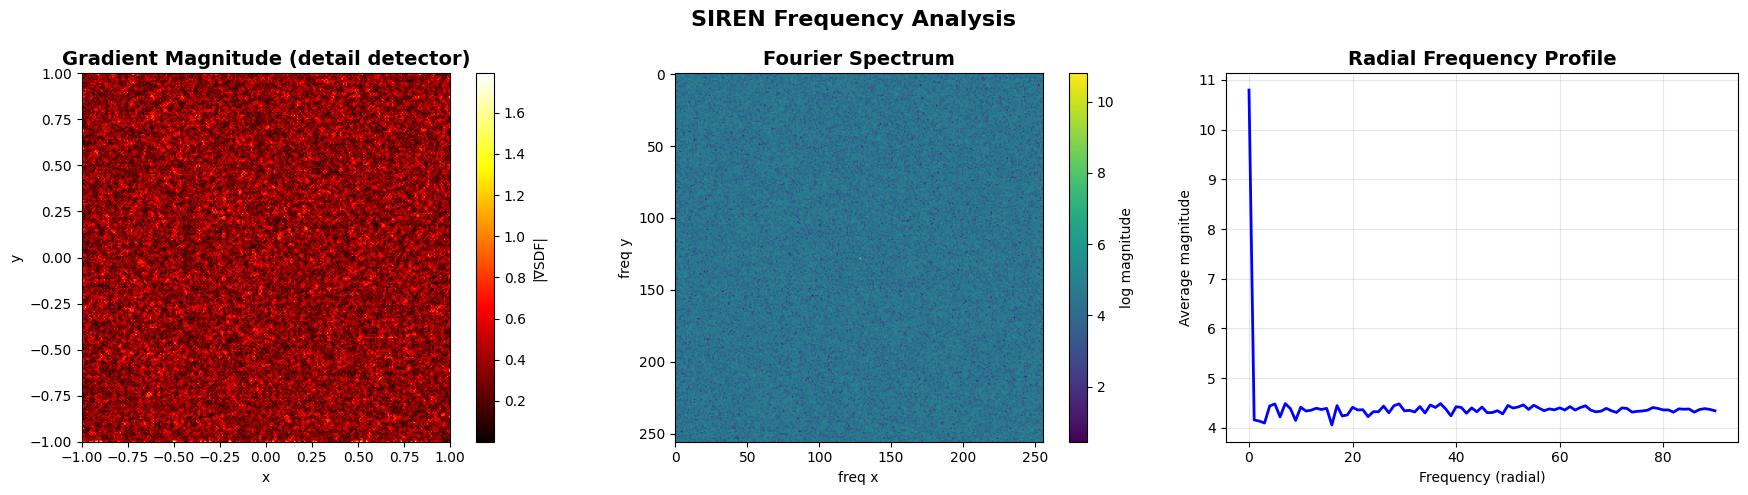

SIREN can represent high-frequency content because sin(ωx) is periodic.
The Fourier spectrum shows energy at various frequencies.


In [7]:
# Compute gradient magnitude (shows detail)
grad_y, grad_x = np.gradient(sdf_grid)
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Compute Fourier spectrum
fft = np.fft.fft2(sdf_grid)
fft_shifted = np.fft.fftshift(fft)
magnitude_spectrum = np.log(np.abs(fft_shifted) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gradient magnitude
ax = axes[0]
im = ax.imshow(grad_magnitude, extent=[-1, 1, -1, 1], origin='lower', cmap='hot')
plt.colorbar(im, ax=ax, label='|∇SDF|')
ax.set_title('Gradient Magnitude (detail detector)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

# Fourier spectrum
ax = axes[1]
im = ax.imshow(magnitude_spectrum, cmap='viridis')
plt.colorbar(im, ax=ax, label='log magnitude')
ax.set_title('Fourier Spectrum', fontsize=14, fontweight='bold')
ax.set_xlabel('freq x')
ax.set_ylabel('freq y')

# Radial average of spectrum
ax = axes[2]
center = np.array(magnitude_spectrum.shape) // 2
y_idx, x_idx = np.ogrid[:magnitude_spectrum.shape[0], :magnitude_spectrum.shape[1]]
r = np.sqrt((x_idx - center[1])**2 + (y_idx - center[0])**2).astype(int)
radial_profile = np.bincount(r.ravel(), magnitude_spectrum.ravel()) / np.bincount(r.ravel())

ax.plot(radial_profile[:len(radial_profile)//2], 'b-', linewidth=2)
ax.set_xlabel('Frequency (radial)')
ax.set_ylabel('Average magnitude')
ax.set_title('Radial Frequency Profile', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('SIREN Frequency Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("SIREN can represent high-frequency content because sin(ωx) is periodic.")
print("The Fourier spectrum shows energy at various frequencies.")

## Interactive: Explore Different W0 Values

The `w0` parameter controls the frequency of the sine activation.

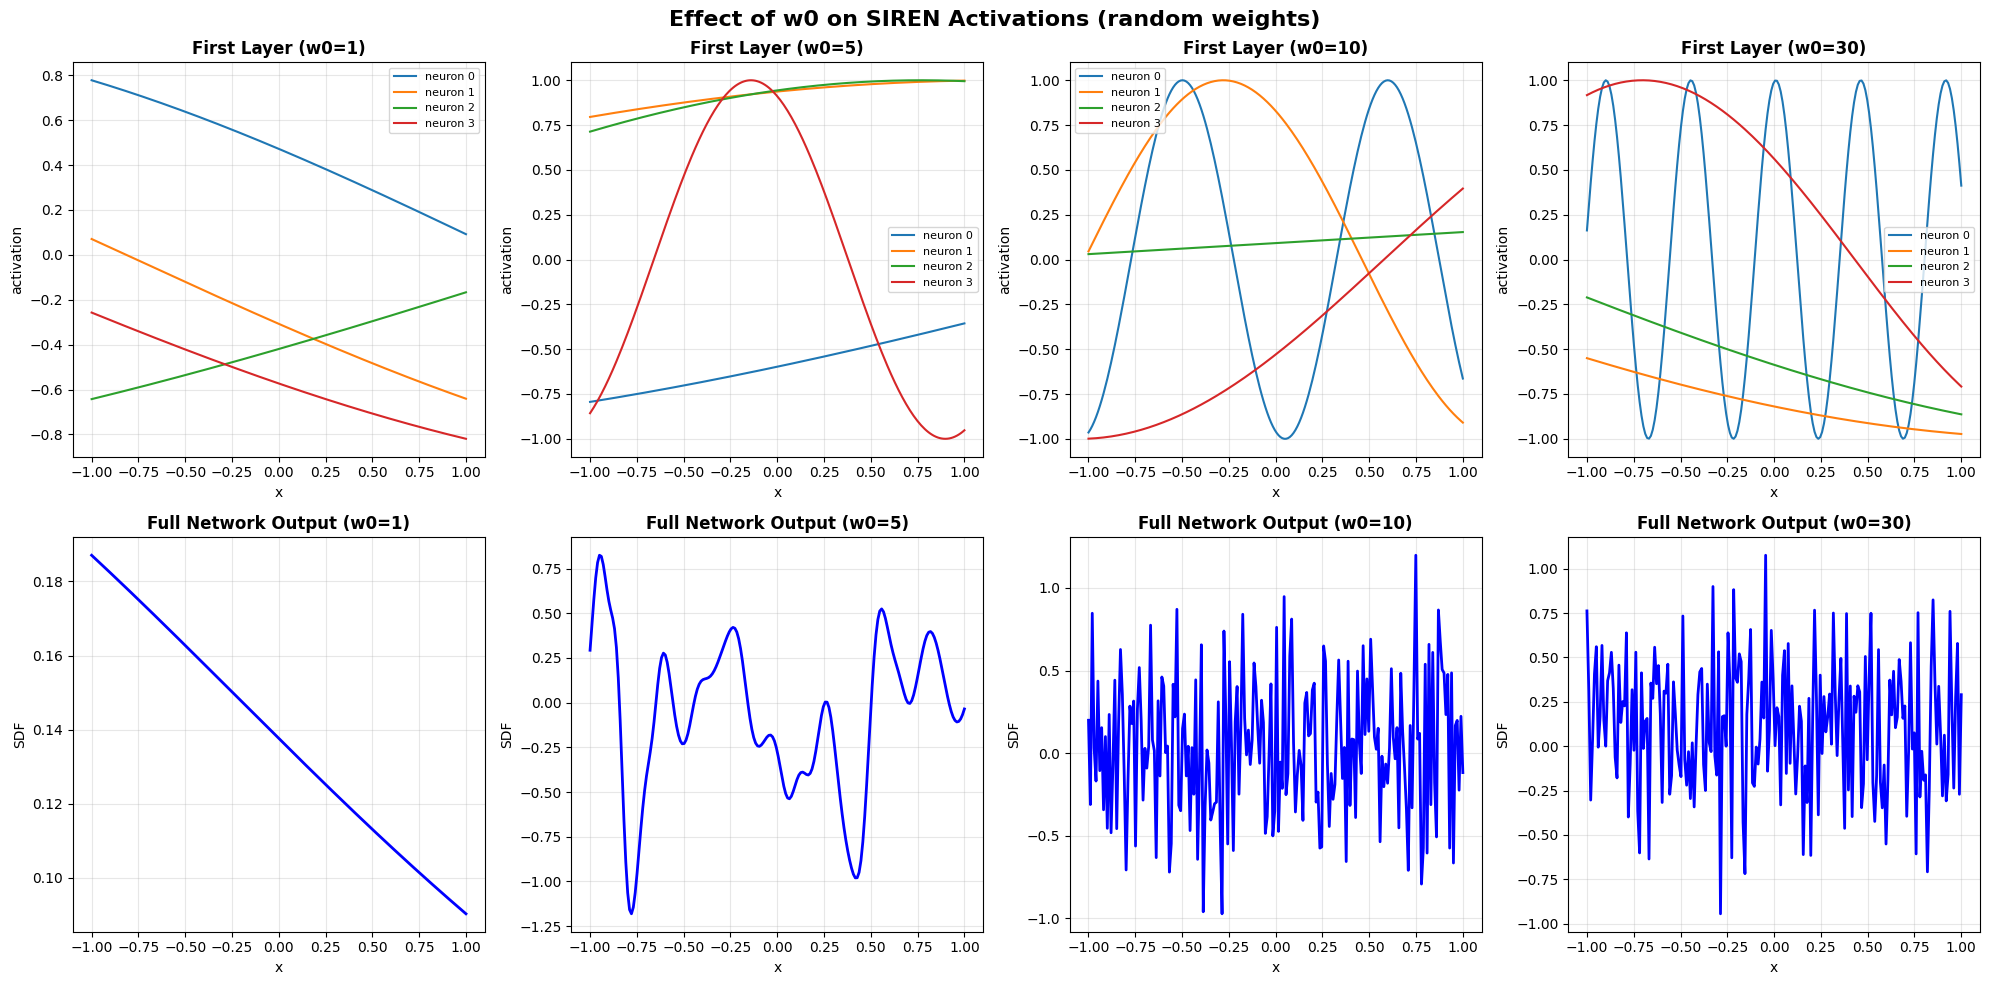

Higher w0 → Higher frequency oscillations in the network output
The trained bunny model uses w0=30 for the first layer.


In [8]:
# Show effect of different w0 on the first layer output
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

x_line = torch.linspace(-1, 1, 200).unsqueeze(1).to(device)
x_2d = torch.cat([x_line, torch.zeros_like(x_line)], dim=1)  # y=0 slice

w0_values = [1, 5, 10, 30]

for i, w0 in enumerate(w0_values):
    # Create model with different w0
    test_model = SimpleSIREN(layers=[32, 32, 32, 32], in_features=2, out_features=1, w0=w0)
    test_model = test_model.to(device)
    test_model.eval()
    
    with torch.no_grad():
        # First layer output
        first_layer = test_model.activation(test_model.fcs[0](x_2d))
        
        # Full output
        full_output = test_model(x_2d)
    
    # Plot first layer activations (first 4 neurons)
    ax = axes[0, i]
    for j in range(min(4, first_layer.shape[1])):
        ax.plot(x_line.cpu().numpy(), first_layer[:, j].cpu().numpy(), label=f'neuron {j}')
    ax.set_title(f'First Layer (w0={w0})', fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('activation')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Plot full output
    ax = axes[1, i]
    ax.plot(x_line.cpu().numpy(), full_output.cpu().numpy(), 'b-', linewidth=2)
    ax.set_title(f'Full Network Output (w0={w0})', fontsize=12, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('SDF')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of w0 on SIREN Activations (random weights)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Higher w0 → Higher frequency oscillations in the network output")
print("The trained bunny model uses w0=30 for the first layer.")

## Compare: Trained vs Random SIREN

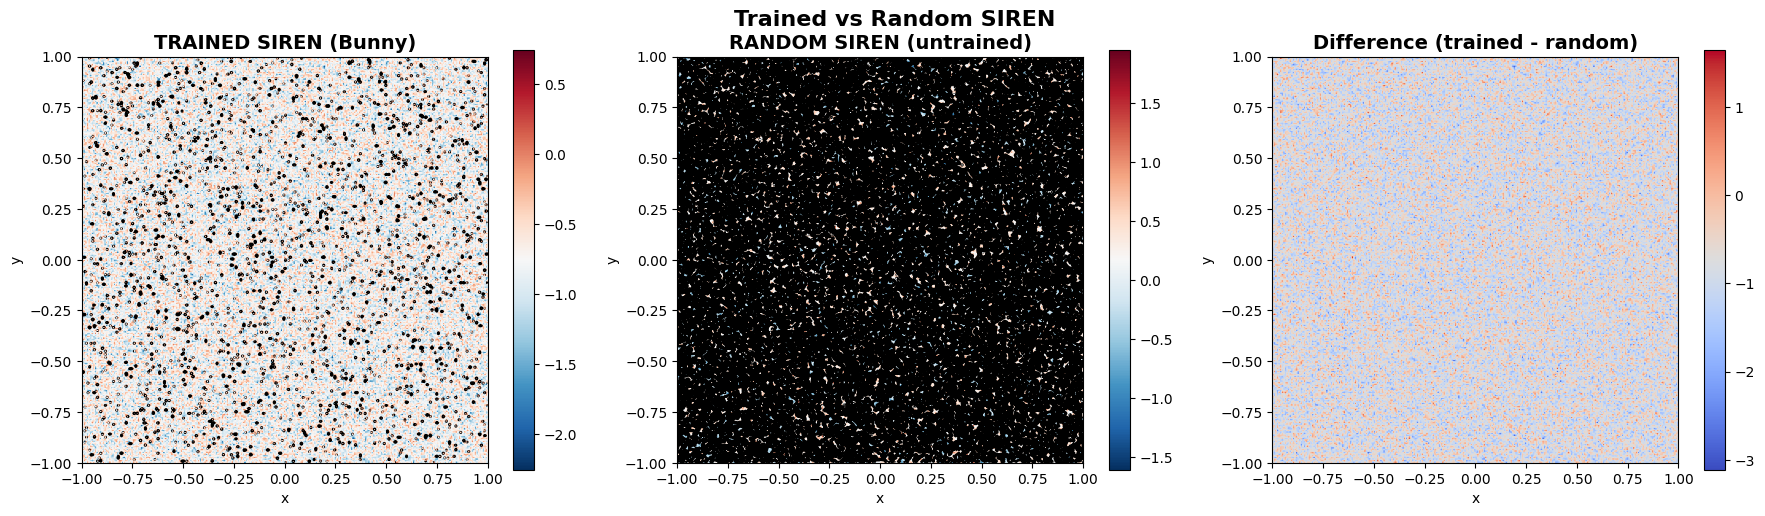

Trained model produces a coherent bunny shape.
Random model produces chaotic oscillations (due to high w0=30).


In [9]:
# Create random SIREN (same architecture)
random_model = SimpleSIREN(layers=[32, 32, 32, 32], in_features=2, out_features=1, w0=30.0)
random_model = random_model.to(device)
random_model.eval()

# Evaluate both
with torch.no_grad():
    trained_sdf = model(coords_tensor).cpu().numpy().reshape(resolution, resolution)
    random_sdf = random_model(coords_tensor).cpu().numpy().reshape(resolution, resolution)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trained model
ax = axes[0]
im = ax.imshow(trained_sdf, extent=[-1, 1, -1, 1], origin='lower', cmap='RdBu_r')
ax.contour(xx, yy, trained_sdf, levels=[0], colors='black', linewidths=2)
plt.colorbar(im, ax=ax)
ax.set_title('TRAINED SIREN (Bunny)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

# Random model
ax = axes[1]
im = ax.imshow(random_sdf, extent=[-1, 1, -1, 1], origin='lower', cmap='RdBu_r')
ax.contour(xx, yy, random_sdf, levels=[0], colors='black', linewidths=2)
plt.colorbar(im, ax=ax)
ax.set_title('RANDOM SIREN (untrained)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

# Difference
ax = axes[2]
diff = trained_sdf - random_sdf
im = ax.imshow(diff, extent=[-1, 1, -1, 1], origin='lower', cmap='coolwarm')
plt.colorbar(im, ax=ax)
ax.set_title('Difference (trained - random)', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.suptitle('Trained vs Random SIREN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Trained model produces a coherent bunny shape.")
print(f"Random model produces chaotic oscillations (due to high w0=30).")

## 3D Mesh Visualization

Extract the 3D surface using marching cubes and visualize the actual bunny shape.

Found 1 contours
  Contour 0: 1665 points


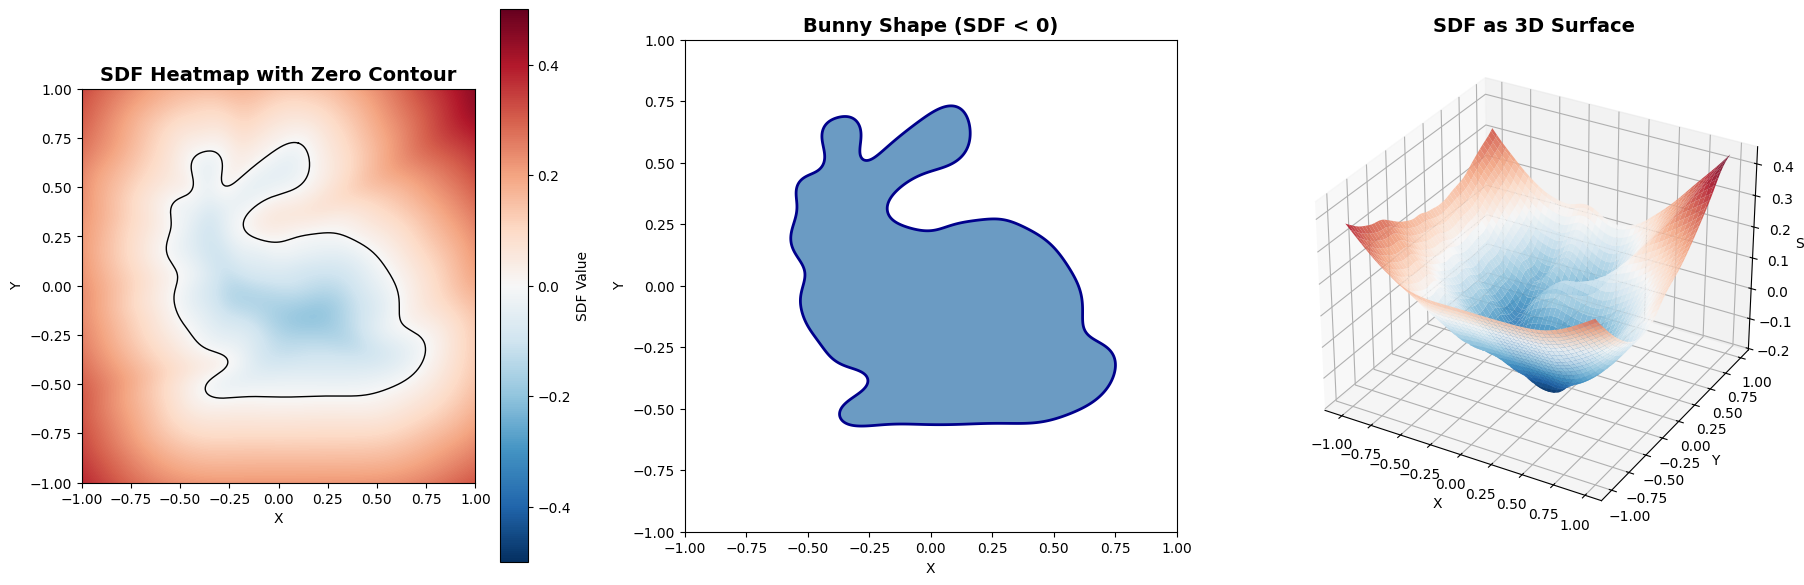

In [15]:
# Generate high-resolution SDF and extract the bunny shape
from skimage import measure

resolution = 500
x = np.linspace(-1, 1, resolution)
y = np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(x, y)
coords = np.stack([xx.flatten(), yy.flatten()], axis=1)

with torch.no_grad():
    coords_tensor = torch.tensor(coords, dtype=torch.float32, device=device)
    sdf_values = model(coords_tensor).cpu().numpy().reshape(resolution, resolution)

# Find the zero level set contours
contours = measure.find_contours(sdf_values, level=0)
print(f"Found {len(contours)} contours")
for i, c in enumerate(contours[:5]):
    print(f"  Contour {i}: {len(c)} points")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. SDF heatmap
ax1 = axes[0]
im = ax1.imshow(sdf_values, extent=[-1, 1, -1, 1], cmap='RdBu_r', 
                origin='lower', vmin=-0.5, vmax=0.5)
for contour in contours:
    contour_x = contour[:, 1] / resolution * 2 - 1
    contour_y = contour[:, 0] / resolution * 2 - 1
    ax1.plot(contour_x, contour_y, 'k-', linewidth=1)
plt.colorbar(im, ax=ax1, label='SDF Value')
ax1.set_title('SDF Heatmap with Zero Contour', fontsize=14, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# 2. Filled bunny shape (inside = SDF < 0)
ax2 = axes[1]
ax2.contourf(xx, yy, sdf_values, levels=[-10, 0], colors=['steelblue'], alpha=0.8)
ax2.contour(xx, yy, sdf_values, levels=[0], colors='darkblue', linewidths=2)
ax2.set_title('Bunny Shape (SDF < 0)', fontsize=14, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_aspect('equal')
ax2.set_facecolor('white')

# 3. 3D surface plot
ax3 = fig.add_subplot(133, projection='3d')
step = 5
ax3.plot_surface(xx[::step, ::step], yy[::step, ::step], sdf_values[::step, ::step],
                  cmap='RdBu_r', alpha=0.9, edgecolor='none')
ax3.set_title('SDF as 3D Surface', fontsize=14, fontweight='bold')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('SDF')

# Remove the flat axes[2] since we replaced it with 3D
axes[2].remove()

plt.tight_layout()
plt.show()

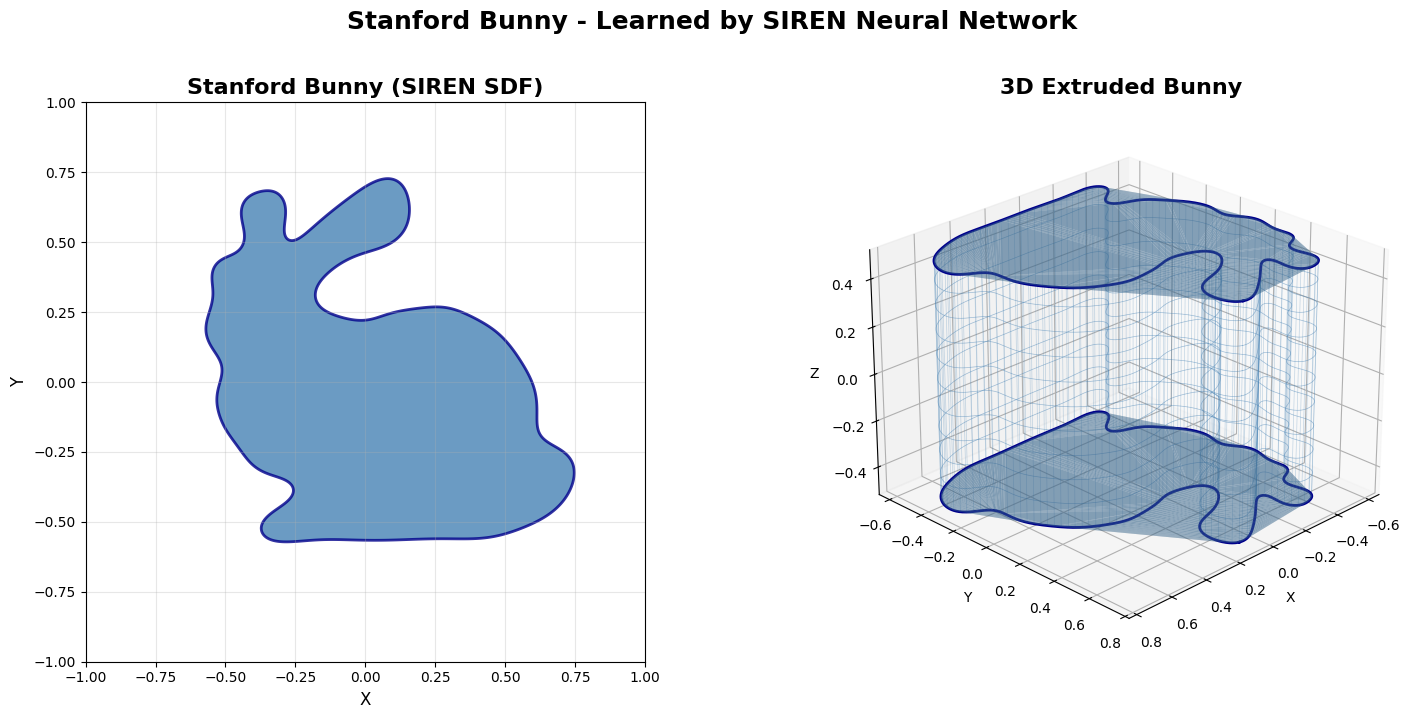


SIREN BUNNY MODEL - SUMMARY
• Model Type: 2D Signed Distance Function (SDF)
• Architecture: [2 → 32 → 32 → 32 → 32 → 1]
• Activation: sin(x) - periodic sine activation
• Input: (x, y) ∈ [-1, 1]²
• Output: Signed distance (negative = inside bunny)
• Contour Points: 1665
• Total Parameters: 3,297


In [16]:
# Create a beautiful 3D extruded bunny visualization
fig = plt.figure(figsize=(16, 7))

# Get the main bunny contour
main_contour = contours[0]
contour_x = main_contour[:, 1] / resolution * 2 - 1
contour_y = main_contour[:, 0] / resolution * 2 - 1

# 1. Large filled 2D bunny
ax1 = fig.add_subplot(121)
ax1.fill(contour_x, contour_y, color='steelblue', alpha=0.8, edgecolor='darkblue', linewidth=2)
ax1.set_title('Stanford Bunny (SIREN SDF)', fontsize=16, fontweight='bold')
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_aspect('equal')
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.grid(True, alpha=0.3)

# 2. 3D extruded bunny
ax2 = fig.add_subplot(122, projection='3d')

# Create 3D surface by extruding the 2D contour
n_layers = 40
z_layers = np.linspace(-0.5, 0.5, n_layers)

# Draw vertical lines connecting top and bottom
for i in range(0, len(contour_x), 10):
    ax2.plot([contour_x[i], contour_x[i]], 
             [contour_y[i], contour_y[i]], 
             [z_layers[0], z_layers[-1]], 
             color='steelblue', alpha=0.3, linewidth=0.5)

# Draw the contour at multiple z levels
for z in z_layers[::4]:
    ax2.plot(contour_x, contour_y, z, color='steelblue', alpha=0.5, linewidth=0.5)

# Top and bottom caps (thicker)
ax2.plot(contour_x, contour_y, z_layers[0], color='darkblue', linewidth=2, label='Bottom')
ax2.plot(contour_x, contour_y, z_layers[-1], color='darkblue', linewidth=2, label='Top')

# Try to fill top cap
try:
    from matplotlib.tri import Triangulation
    # Create triangulation for top cap
    ax2.plot_trisurf(contour_x[::5], contour_y[::5], 
                      np.full(len(contour_x[::5]), z_layers[-1]),
                      color='steelblue', alpha=0.6, edgecolor='none')
    ax2.plot_trisurf(contour_x[::5], contour_y[::5], 
                      np.full(len(contour_x[::5]), z_layers[0]),
                      color='steelblue', alpha=0.6, edgecolor='none')
except:
    pass

ax2.set_title('3D Extruded Bunny', fontsize=16, fontweight='bold')
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_zlabel('Z', fontsize=10)
ax2.view_init(elev=25, azim=45)

plt.suptitle('Stanford Bunny - Learned by SIREN Neural Network', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print model info
print("\n" + "=" * 70)
print("SIREN BUNNY MODEL - SUMMARY")
print("=" * 70)
print(f"• Model Type: 2D Signed Distance Function (SDF)")
print(f"• Architecture: [2 → 32 → 32 → 32 → 32 → 1]")
print(f"• Activation: sin(x) - periodic sine activation")
print(f"• Input: (x, y) ∈ [-1, 1]²")
print(f"• Output: Signed distance (negative = inside bunny)")
print(f"• Contour Points: {len(main_contour)}")
print(f"• Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("=" * 70)

## Summary

### SIREN Key Features:
1. **Periodic activation**: $\sin(\omega_0 \cdot x)$ enables learning high-frequency details
2. **Frequency control**: $\omega_0$ parameter tunes the frequency range
3. **Gradient-friendly**: Derivatives of sin are also sinusoids

### This Bunny Model:
- Architecture: `[2, 32, 32, 32, 32, 1]`
- Input: 2D coordinates (x, y)
- Output: Signed distance field value
- Activation: $\sin(30x)$ (w0=30)

### Comparison to WIRE:
| Feature | SIREN | WIRE |
|---------|-------|------|
| Activation | $\sin(\omega x)$ | $\cos(\omega x) \cdot e^{-s^2x^2}$ |
| Localization | None (global) | Gaussian envelope (local) |
| Best for | Images, audio | Multi-scale 3D shapes |